Here goes source for synthetic data variate
Synthetic GAN is used Generative Adverisial Neural Networking
https://docs.sdv.dev/sdv/single-table-data/data-preparation/loading-data

! pip install sdv

In [1]:
import sdv


print(sdv.version.public)

1.19.0


# Dataset preprocessing 

In [4]:
import pandas as pd
dataset=pd.read_csv('breach_report.csv')
dataset.sample()

,name_of_covered_entity,state,covered_entity_type,individuals_affected,breach_submission_date,type_of_breach,location_of_breached_information,business_associate_present,web_description
414,Louis A. Johnson Veterans' Administration Medi...,WV,Healthcare Provider,736,12/20/2022,Unauthorized Access/Disclosure,Paper/Films,No,NaN


# Load the CSV file

In [9]:
from sdv.datasets.local import load_csvs

# Load the CSV file from the 'data' folder
datasets = load_csvs(
    folder_name='data',  # Specify the correct folder name where the file is located
    read_csv_parameters={
        'skipinitialspace': True,
        'encoding': 'utf-8'  # Changed encoding to UTF-8
    })

# the data is available under the file name
data = datasets['breach_report']

# Display a sample of the dataset
print(data.head())

          name_of_covered_entity state  covered_entity_type  \
0          iTrust Wellness Group    SC  Healthcare Provider   
1                  Madera County    CA          Health Plan   
2    PCC Pediatric EHR Solutions    VT   Business Associate   
3             Premera Blue Cross    WA          Health Plan   
4  Redwood Coast Regional Center    CA  Healthcare Provider   

   individuals_affected breach_submission_date  \
0                   981              8/10/2023   
1                  1146               8/9/2023   
2                   520               8/9/2023   
3                 33212               8/8/2023   
4                  1345               8/7/2023   

                   type_of_breach location_of_breached_information  \
0             Hacking/IT Incident                            Email   
1  Unauthorized Access/Disclosure                            Email   
2  Unauthorized Access/Disclosure                            Email   
3             Hacking/IT Incident       

In [10]:
from sdv.metadata import Metadata


# Detect data from dataframe

In [15]:
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframe(
    data=data,
    table_name='breach_report')

# Create the Syntheisized data

In [17]:
from sdv.single_table import GaussianCopulaSynthesizer


In [18]:
# Step 1: Create the synthesizer
synthesizer = GaussianCopulaSynthesizer(metadata)


/home/pradyumnakubear/anaconda3/envs/first_python_env/lib/python3.9/site-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


# Step 2: Train the synthesizer


In [20]:
synthesizer.fit(data)



# Step 3: Generate synthetic data


In [22]:
synthetic_data = synthesizer.sample(num_rows=100)

# Step 4 Define the Synthesizer

In [30]:
from sdv.single_table import GaussianCopulaSynthesizer


# Create the synthesizer

In [32]:
synthesizer = GaussianCopulaSynthesizer(metadata)


/home/pradyumnakubear/anaconda3/envs/first_python_env/lib/python3.9/site-packages/sdv/single_table/base.py:119: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


# Fit the model
Model has learnt here

In [34]:
synthesizer.fit(data)

# Generate the model

In [35]:
synthetic_data = synthesizer.sample(num_rows=500)

In [36]:
print(synthetic_data.head())


  name_of_covered_entity           state  covered_entity_type  \
0          sdv-pii-8qst0        New York          Health Plan   
1          sdv-pii-vtj89  North Carolina  Healthcare Provider   
2          sdv-pii-w7aog          Oregon  Healthcare Provider   
3          sdv-pii-4vyyx    Pennsylvania  Healthcare Provider   
4          sdv-pii-nw1d7            Iowa          Health Plan   

   individuals_affected breach_submission_date  \
0                 54795             11/13/2022   
1                  1274             09/21/2022   
2                 17923             04/17/2022   
3                  1173             01/12/2022   
4                  1678             05/15/2023   

                   type_of_breach location_of_breached_information  \
0             Hacking/IT Incident                            Email   
1             Hacking/IT Incident                   Network Server   
2             Hacking/IT Incident                   Network Server   
3             Hacking/IT Inc

# Do you have any sensitive data? The transformations are also used for anonymizing or pseudo-anonymizing sensitive data.

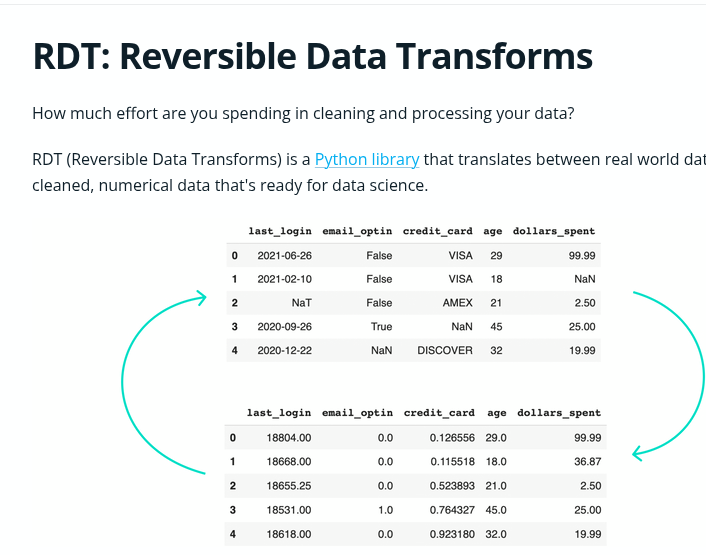

In [40]:
from IPython.display import Image
Image(filename='data/HidingSensitiveData.png')


In [41]:
synthesizer.fit(data)

# Save the Data

In [42]:
synthetic_data = synthesizer.sample(num_rows=1_000_000)

In [43]:
synthetic_data.to_csv('synthetic_data.csv', index=False)

# Evaluate the data

In [45]:
# Load real data from CSV
real_data = pd.read_csv('data/breach_report.csv')

# Load synthetic data from CSV
synthetic_data = pd.read_csv('synthetic_data.csv')

# Drop the 'covered_entity_type' column from both datasets
real_data = real_data.drop(columns=['covered_entity_type'])
synthetic_data = synthetic_data.drop(columns=['covered_entity_type'])

# Update metadata 

In [46]:
metadata = {
    'state': 'categorical',
    'individuals_affected': 'numerical',
    'breach_submission_date': 'datetime',
    'type_of_breach': 'categorical',
    'location_of_breached_information': 'categorical',
    'business_associate_present': 'categorical'
}


# Run the diagnostic test

In [59]:
from sdv.metadata import Metadata
from sdv.evaluation.single_table import run_diagnostic, evaluate_quality
import pandas as pd

# Assuming real_data and synthetic_data are already defined as pandas DataFrames
# Create metadata object
metadata = Metadata()

# Define a table to add columns to
metadata.add_table('breach_data')

# Adding columns to the table in the metadata
metadata.add_column(column_name='state', table_name='breach_data', sdtype='categorical')
metadata.add_column(column_name='covered_entity_type', table_name='breach_data', sdtype='categorical')
metadata.add_column(column_name='individuals_affected', table_name='breach_data', sdtype='numerical')
metadata.add_column(column_name='breach_submission_date', table_name='breach_data', sdtype='datetime')
metadata.add_column(column_name='type_of_breach', table_name='breach_data', sdtype='categorical')
metadata.add_column(column_name='location_of_breached_information', table_name='breach_data', sdtype='categorical')
metadata.add_column(column_name='business_associate_present', table_name='breach_data', sdtype='categorical')
metadata.add_column(column_name='web_description', table_name='breach_data', sdtype='categorical')

# If the column `name_of_covered_entity` is in your data, make sure to add it to the metadata
metadata.add_column(column_name='name_of_covered_entity', table_name='breach_data', sdtype='categorical')

# 1. Perform basic validity checks
diagnostic = run_diagnostic(real_data, synthetic_data, metadata)

# 2. Measure the statistical similarity
quality_report = evaluate_quality(real_data, synthetic_data, metadata)

# Print the diagnostic and quality results
print(diagnostic)
print(quality_report)


Generating report ...

(1/2) Evaluating Data Validity: |█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 24.53it/s]|
Data Validity Score: 75.04%

(2/2) Evaluating Data Structure: |███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 542.81it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 87.52%



ValueError: The metadata does not match the data. The following columns are missing in the real/synthetic data or in the metadata: covered_entity_type